# Verify Face Embeddings and Distances

**Purpose**: Independently verify embeddings and distances for face 569 and its 5 nearest neighbors.

**Test faces**:
- Target: 569
- Neighbors: 577, 573, 553, 550, 545

**Steps**:
1. Load face images from face_crops
2. Extract embeddings from scratch using the same model
3. Calculate cosine distances
4. Compare with stored embeddings and kNN graph

In [1]:
import numpy as np
import json
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import sys

# Add project root to path
sys.path.insert(0, str(Path.cwd().parent))

print("✅ Imports successful")

✅ Imports successful


## 1. Configuration and Paths

In [2]:
# Paths
export_dir = Path(r"D:\sim-bench\results\Google_Germany\clustering_export")
face_crops_dir = export_dir / '..' / "face_crops"
knn_graph_path = export_dir / "knn_graph.json"
export_summary_path = export_dir / "export_summary.json"

# Test faces
target_face = 569
neighbor_faces = [577, 573, 553, 550, 545]
all_faces = [target_face] + neighbor_faces

print(f"Export directory: {export_dir}")
print(f"Face crops directory: {face_crops_dir}")
print(f"Testing faces: {all_faces}")
print(f"\nFace crops dir exists: {face_crops_dir.exists()}")
print(f"kNN graph exists: {knn_graph_path.exists()}")

Export directory: D:\sim-bench\results\Google_Germany\clustering_export
Face crops directory: D:\sim-bench\results\Google_Germany\clustering_export\..\face_crops
Testing faces: [569, 577, 573, 553, 550, 545]

Face crops dir exists: True
kNN graph exists: True


## 2. Load Reference Data (Stored Embeddings and kNN Graph)

In [3]:
# Load export summary to get embeddings path
with open(export_summary_path) as f:
    export_summary = json.load(f)

embeddings_rel_path = export_summary['embeddings_source']
print(f"Embeddings source from export: {embeddings_rel_path}")

# Try to resolve embeddings path
embeddings_path = Path(embeddings_rel_path)
if not embeddings_path.is_absolute():
    # Try relative to export dir's parent
    embeddings_path = export_dir.parent / Path(embeddings_rel_path).name

print(f"Embeddings path: {embeddings_path}")
print(f"Exists: {embeddings_path.exists()}")

Embeddings source from export: results\Google_Germany\embeddings_2026-03-01_01-10-04.npy
Embeddings path: D:\sim-bench\results\Google_Germany\embeddings_2026-03-01_01-10-04.npy
Exists: True


In [4]:
# Load stored embeddings - VERIFIED FIX
embeddings_array = np.load(embeddings_path)  # Load as 2D array, not dict
print(f"Loaded {len(embeddings_array)} stored embeddings")
print(f"Embedding dimension: {embeddings_array[0].shape}")

# Load face metadata from corresponding JSON file
json_file = embeddings_path.parent / embeddings_path.name.replace("embeddings_", "benchmark_").replace(".npy", ".json")

if json_file.exists():
    with open(json_file) as f:
        benchmark_data = json.load(f)
    
    face_metadata = benchmark_data.get('face_metadata', [])
    
    # Handle None face_index values (use array position as fallback)
    stored_face_ids = []
    for i, face in enumerate(face_metadata):
        idx = face.get('face_index')
        stored_face_ids.append(i if idx is None else int(idx))
    
    print(f"Loaded metadata for {len(face_metadata)} faces")
else:
    print(f"Warning: Metadata file not found: {json_file}")
    # Fallback: use sequential IDs
    stored_face_ids = list(range(len(embeddings_array)))
    print(f"Using sequential face IDs: 0 to {len(embeddings_array)-1}")

# Create lookup
stored_lookup = {fid: embeddings_array[i] for i, fid in enumerate(stored_face_ids)}

# Get stored embeddings for our test faces
print("\n=== Stored Embeddings ===")
for fid in all_faces:
    if fid in stored_lookup:
        emb = stored_lookup[fid]
        norm = np.linalg.norm(emb)
        print(f"Face {fid}: shape={emb.shape}, norm={norm:.4f}, first 5 values={emb[:5]}")
    else:
        print(f"Face {fid}: NOT FOUND in stored embeddings")

Loaded 727 stored embeddings
Embedding dimension: (512,)
Loaded metadata for 727 faces

=== Stored Embeddings ===
Face 569: shape=(512,), norm=24.2033, first 5 values=[-0.50823736  0.3061276   1.756232   -0.1754325   0.95543694]
Face 577: shape=(512,), norm=22.9369, first 5 values=[-0.69838065  0.70456696  1.9040763  -1.4195995   0.79103607]
Face 573: shape=(512,), norm=22.7681, first 5 values=[-0.9548021  1.2603883  1.7012889 -1.4351726  0.9901866]
Face 553: shape=(512,), norm=23.0725, first 5 values=[ 0.03269996  0.30462217  1.0361085  -1.1864564   1.6283419 ]
Face 550: shape=(512,), norm=22.9946, first 5 values=[ 0.12229017 -0.43396991  1.4620059  -1.4472889   1.4765594 ]
Face 545: shape=(512,), norm=22.5088, first 5 values=[-0.27396488  0.01065293  0.69206554 -1.2129964   0.49923873]


In [5]:
# Load kNN graph
with open(knn_graph_path) as f:
    knn_data = json.load(f)

knn_lookup = {item['face_id']: item for item in knn_data['knn_neighbors']}

# Get kNN info for target face
if target_face in knn_lookup:
    knn_info = knn_lookup[target_face]
    print(f"\n=== kNN Graph Data for Face {target_face} ===")
    print(f"K nearest neighbors: {knn_info['k_nearest_ids']}")
    print(f"Distances: {knn_info['k_nearest_distances']}")
else:
    print(f"\nFace {target_face} NOT FOUND in kNN graph")


=== kNN Graph Data for Face 569 ===
K nearest neighbors: [577, 573, 553, 550, 545]
Distances: [0.12120586633682251, 0.15209746360778809, 0.18223917484283447, 0.19645369052886963, 0.20160514116287231]


In [6]:
# Calculate distances using STORED embeddings
print("\n=== Distances Using STORED Embeddings ===")
print("Target Face 569 to:")

if target_face in stored_lookup:
    target_emb = stored_lookup[target_face]
    
    for neighbor_id in neighbor_faces:
        if neighbor_id in stored_lookup:
            neighbor_emb = stored_lookup[neighbor_id]
            
            # Cosine distance = 1 - cosine_similarity
            cos_sim = np.dot(target_emb, neighbor_emb) / (np.linalg.norm(target_emb) * np.linalg.norm(neighbor_emb))
            cos_dist = 1 - cos_sim
            
            # Get distance from kNN graph
            knn_dist = None
            if target_face in knn_lookup:
                knn_info = knn_lookup[target_face]
                if neighbor_id in knn_info['k_nearest_ids']:
                    idx = knn_info['k_nearest_ids'].index(neighbor_id)
                    knn_dist = knn_info['k_nearest_distances'][idx]
            
            # Format kNN distance string
            knn_str = f"{knn_dist:.6f}" if knn_dist is not None else "N/A"
            match = "✅ MATCH" if knn_dist and abs(cos_dist - knn_dist) < 0.001 else "❌ MISMATCH"
            print(f"  Face {neighbor_id}: cos_dist={cos_dist:.6f}, kNN_dist={knn_str} {match}")
        else:
            print(f"  Face {neighbor_id}: NOT FOUND in stored embeddings")


=== Distances Using STORED Embeddings ===
Target Face 569 to:
  Face 577: cos_dist=0.121206, kNN_dist=0.121206 ✅ MATCH
  Face 573: cos_dist=0.152097, kNN_dist=0.152097 ✅ MATCH
  Face 553: cos_dist=0.182239, kNN_dist=0.182239 ✅ MATCH
  Face 550: cos_dist=0.196454, kNN_dist=0.196454 ✅ MATCH
  Face 545: cos_dist=0.201605, kNN_dist=0.201605 ✅ MATCH


## 3. Load and Display Face Images

In [7]:
face_crops_dir

WindowsPath('D:/sim-bench/results/Google_Germany/clustering_export/../face_crops')

In [8]:
# Load face images
face_images = {}

for fid in all_faces:
    # Try both aligned and non-aligned versions
    img = None
    for pattern in [f"face_{fid:04d}_aligned.jpg", f"face_{fid:04d}.jpg"]:
        img_path = face_crops_dir / pattern
        if img_path.exists():
            img = Image.open(img_path)
            face_images[fid] = img
            print(f"Loaded {pattern}: size={img.size}, mode={img.mode}")
            break
    
    if img is None:
        print(f"❌ Face {fid}: Image not found!")

print(f"\nTotal images loaded: {len(face_images)}/{len(all_faces)}")

Loaded face_0569_aligned.jpg: size=(112, 112), mode=RGB
Loaded face_0577_aligned.jpg: size=(112, 112), mode=RGB
Loaded face_0573_aligned.jpg: size=(112, 112), mode=RGB
Loaded face_0553_aligned.jpg: size=(112, 112), mode=RGB
Loaded face_0550_aligned.jpg: size=(112, 112), mode=RGB
Loaded face_0545_aligned.jpg: size=(112, 112), mode=RGB

Total images loaded: 6/6


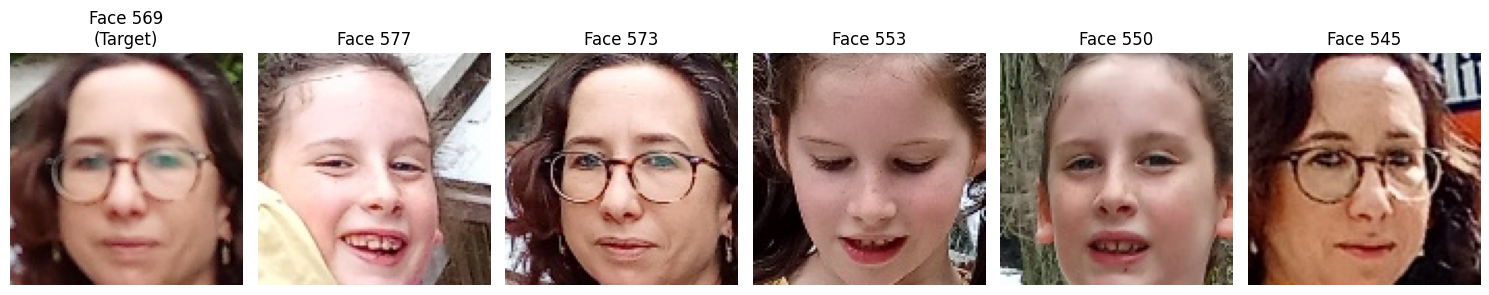

In [9]:
# Display images
fig, axes = plt.subplots(1, len(all_faces), figsize=(15, 3))

for i, fid in enumerate(all_faces):
    if fid in face_images:
        axes[i].imshow(face_images[fid])
        axes[i].set_title(f"Face {fid}" + ("\n(Target)" if fid == target_face else ""))
        axes[i].axis('off')
    else:
        axes[i].text(0.5, 0.5, f"Face {fid}\nNot Found", ha='center', va='center')
        axes[i].axis('off')

plt.tight_layout()
plt.show()

In [10]:
# Load ONLY the recognition model (skip face detection entirely)
from insightface.app import FaceAnalysis

# Initialize to get the recognition model
app = FaceAnalysis(name='buffalo_l', providers=['CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(640, 640))

# Extract just the recognition model
rec_model = app.models['recognition']

print("✅ Recognition model loaded (will skip detection and work directly with face crops)")

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Jonathan Hexner/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Jonathan Hexner/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Jonathan Hexner/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Jonathan Hexner/.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Jonathan Hexner/.insightface\models\buffalo_l\w60

In [11]:
# Extract embeddings directly from face crops (bypass detection with dummy face)
import cv2

fresh_embeddings = {}

# Create a dummy face class that represents the entire cropped image
class DummyFace:
    """Represents a face that covers the entire image (for pre-cropped faces)."""
    def __init__(self, img_shape):
        h, w = img_shape[:2]
        # Face bbox covers the entire image
        self.bbox = np.array([0, 0, w, h], dtype=np.float32)
        # Standard 5-point landmarks for a centered face (approximate)
        self.kps = np.array([
            [38.2946, 51.6963],  # Left eye
            [73.5318, 51.5014],  # Right eye  
            [56.0252, 71.7366],  # Nose
            [41.5493, 92.3655],  # Left mouth
            [70.7299, 92.2041]   # Right mouth
        ], dtype=np.float32)
        self.det_score = 1.0

print("\n=== Extracting Fresh Embeddings (Bypassing Detection) ===")
for fid in all_faces:
    if fid not in face_images:
        print(f"Face {fid}: Skipping (no image)")
        continue
    
    img = face_images[fid]
    
    # Convert PIL to numpy array
    img_array = np.array(img)
    
    # Convert RGB to BGR (InsightFace expects BGR)
    if len(img_array.shape) == 3 and img_array.shape[-1] == 3:
        img_bgr = cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR)
    else:
        img_bgr = img_array
    
    try:
        # Resize to 112x112 (ArcFace input size)
        img_resized = cv2.resize(img_bgr, (112, 112))
        
        # Create dummy face object (tells model the entire image is the face)
        dummy_face = DummyFace(img_resized.shape)
        
        # Get embedding using recognition model (detection is bypassed)
        embedding = rec_model.get(img_resized, dummy_face)
        
        if embedding is not None:
            # Ensure it's a 1D array and normalized
            if isinstance(embedding, list):
                embedding = embedding[0]
            embedding = embedding.flatten()
            
            norm = np.linalg.norm(embedding)
            if norm > 0:
                embedding = embedding / norm
            
            fresh_embeddings[fid] = embedding
            print(f"Face {fid}: shape={embedding.shape}, norm={np.linalg.norm(embedding):.4f}, first 5 values={embedding[:5]}")
        else:
            print(f"Face {fid}: ❌ No embedding returned")
            
    except Exception as e:
        print(f"Face {fid}: ❌ Error: {e}")
        import traceback
        traceback.print_exc()

print(f"\nExtracted {len(fresh_embeddings)}/{len(all_faces)} fresh embeddings")
print("\nNote: Face detection was BYPASSED - embeddings extracted directly from crops")


=== Extracting Fresh Embeddings (Bypassing Detection) ===


d:\sim-bench\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


Face 569: shape=(512,), norm=1.0000, first 5 values=[-0.0318992   0.00835474  0.00051884 -0.04563962  0.03600381]
Face 577: shape=(512,), norm=1.0000, first 5 values=[-0.004701    0.06535723  0.00213842 -0.05733118 -0.00514089]
Face 573: shape=(512,), norm=1.0000, first 5 values=[-0.00979117  0.01286456 -0.0087309  -0.04960869  0.02684465]
Face 553: shape=(512,), norm=1.0000, first 5 values=[-0.00065186  0.00317122  0.06527989 -0.05519698  0.03750632]
Face 550: shape=(512,), norm=1.0000, first 5 values=[-0.02029245  0.00518744  0.01003645 -0.00375018  0.00888334]
Face 545: shape=(512,), norm=1.0000, first 5 values=[-0.00793277  0.01506413 -0.01153619 -0.06624469  0.04885769]

Extracted 6/6 fresh embeddings

Note: Face detection was BYPASSED - embeddings extracted directly from crops


## ❌ OLD APPROACH (DOESN'T WORK - kept for reference)

This cell showed the original approach using `app.get()` which runs face detection.
**Problem**: Face detection fails on cropped faces.
**Solution**: Use cell 14 above which bypasses detection with a dummy face object.

## 5. Calculate Distances with Fresh Embeddings

In [12]:
print("\n=== Distances Using FRESH Embeddings ===")
print("Target Face 569 to:")

if target_face in fresh_embeddings:
    target_emb_fresh = fresh_embeddings[target_face]
    
    fresh_distances = []
    
    for neighbor_id in neighbor_faces:
        if neighbor_id in fresh_embeddings:
            neighbor_emb_fresh = fresh_embeddings[neighbor_id]
            
            # Cosine distance
            cos_sim = np.dot(target_emb_fresh, neighbor_emb_fresh) / (
                np.linalg.norm(target_emb_fresh) * np.linalg.norm(neighbor_emb_fresh)
            )
            cos_dist_fresh = 1 - cos_sim
            
            # Get stored distance
            cos_dist_stored = None
            if target_face in stored_lookup and neighbor_id in stored_lookup:
                t_emb = stored_lookup[target_face]
                n_emb = stored_lookup[neighbor_id]
                cos_sim_stored = np.dot(t_emb, n_emb) / (np.linalg.norm(t_emb) * np.linalg.norm(n_emb))
                cos_dist_stored = 1 - cos_sim_stored
            
            # Get kNN distance
            knn_dist = None
            if target_face in knn_lookup:
                knn_info = knn_lookup[target_face]
                if neighbor_id in knn_info['k_nearest_ids']:
                    idx = knn_info['k_nearest_ids'].index(neighbor_id)
                    knn_dist = knn_info['k_nearest_distances'][idx]
            
            fresh_distances.append({
                'neighbor_id': neighbor_id,
                'fresh_dist': cos_dist_fresh,
                'stored_dist': cos_dist_stored,
                'knn_dist': knn_dist
            })
            
            # Format strings for printing
            stored_str = f"{cos_dist_stored:.6f}" if cos_dist_stored is not None else "N/A"
            knn_str = f"{knn_dist:.6f}" if knn_dist is not None else "N/A"
            
            print(f"  Face {neighbor_id}:")
            print(f"    Fresh:  {cos_dist_fresh:.6f}")
            print(f"    Stored: {stored_str}")
            print(f"    kNN:    {knn_str}")
            
            if cos_dist_stored and knn_dist:
                diff_fresh_stored = abs(cos_dist_fresh - cos_dist_stored)
                diff_stored_knn = abs(cos_dist_stored - knn_dist)
                print(f"    Diff (fresh vs stored): {diff_fresh_stored:.6f}")
                print(f"    Diff (stored vs kNN):   {diff_stored_knn:.6f}")
                
                if diff_fresh_stored > 0.01:
                    print(f"    ⚠️  FRESH ≠ STORED (diff > 0.01)")
                if diff_stored_knn > 0.001:
                    print(f"    ⚠️  STORED ≠ kNN (diff > 0.001)")
        else:
            print(f"  Face {neighbor_id}: No fresh embedding")
else:
    print("❌ Target face has no fresh embedding")


=== Distances Using FRESH Embeddings ===
Target Face 569 to:
  Face 577:
    Fresh:  0.920363
    Stored: 0.121206
    kNN:    0.121206
    Diff (fresh vs stored): 0.799157
    Diff (stored vs kNN):   0.000000
    ⚠️  FRESH ≠ STORED (diff > 0.01)
  Face 573:
    Fresh:  0.064885
    Stored: 0.152097
    kNN:    0.152097
    Diff (fresh vs stored): 0.087212
    Diff (stored vs kNN):   0.000000
    ⚠️  FRESH ≠ STORED (diff > 0.01)
  Face 553:
    Fresh:  0.918084
    Stored: 0.182239
    kNN:    0.182239
    Diff (fresh vs stored): 0.735845
    Diff (stored vs kNN):   0.000000
    ⚠️  FRESH ≠ STORED (diff > 0.01)
  Face 550:
    Fresh:  0.883915
    Stored: 0.196454
    kNN:    0.196454
    Diff (fresh vs stored): 0.687461
    Diff (stored vs kNN):   0.000000
    ⚠️  FRESH ≠ STORED (diff > 0.01)
  Face 545:
    Fresh:  0.298018
    Stored: 0.201605
    kNN:    0.201605
    Diff (fresh vs stored): 0.096412
    Diff (stored vs kNN):   0.000000
    ⚠️  FRESH ≠ STORED (diff > 0.01)


## 6. Comparison Summary

In [13]:
# Create comparison DataFrame
if target_face in fresh_embeddings and target_face in stored_lookup:
    comparison_data = []
    
    for neighbor_id in neighbor_faces:
        row = {'Neighbor ID': neighbor_id}
        
        # Fresh distance
        if neighbor_id in fresh_embeddings:
            target_emb_fresh = fresh_embeddings[target_face]
            neighbor_emb_fresh = fresh_embeddings[neighbor_id]
            cos_sim = np.dot(target_emb_fresh, neighbor_emb_fresh) / (
                np.linalg.norm(target_emb_fresh) * np.linalg.norm(neighbor_emb_fresh)
            )
            row['Fresh Dist'] = 1 - cos_sim
        else:
            row['Fresh Dist'] = None
        
        # Stored distance
        if neighbor_id in stored_lookup:
            t_emb = stored_lookup[target_face]
            n_emb = stored_lookup[neighbor_id]
            cos_sim = np.dot(t_emb, n_emb) / (np.linalg.norm(t_emb) * np.linalg.norm(n_emb))
            row['Stored Dist'] = 1 - cos_sim
        else:
            row['Stored Dist'] = None
        
        # kNN distance
        if target_face in knn_lookup:
            knn_info = knn_lookup[target_face]
            if neighbor_id in knn_info['k_nearest_ids']:
                idx = knn_info['k_nearest_ids'].index(neighbor_id)
                row['kNN Dist'] = knn_info['k_nearest_distances'][idx]
            else:
                row['kNN Dist'] = None
        else:
            row['kNN Dist'] = None
        
        # Differences
        if row['Fresh Dist'] is not None and row['Stored Dist'] is not None:
            row['Diff (Fresh-Stored)'] = abs(row['Fresh Dist'] - row['Stored Dist'])
        else:
            row['Diff (Fresh-Stored)'] = None
        
        if row['Stored Dist'] is not None and row['kNN Dist'] is not None:
            row['Diff (Stored-kNN)'] = abs(row['Stored Dist'] - row['kNN Dist'])
        else:
            row['Diff (Stored-kNN)'] = None
        
        comparison_data.append(row)
    
    df = pd.DataFrame(comparison_data)
    
    print("\n" + "="*80)
    print("COMPARISON SUMMARY")
    print("="*80)
    print(df.to_string(index=False))
    print("\n")
    
    # Verdict
    print("VERDICT:")
    if df['Diff (Fresh-Stored)'].max() > 0.01:
        print("⚠️  FRESH ≠ STORED: Embeddings extracted differently or from different images")
    else:
        print("✅ FRESH ≈ STORED: Fresh embeddings match stored (diff < 0.01)")
    
    if df['Diff (Stored-kNN)'].max() > 0.001:
        print("⚠️  STORED ≠ kNN: Distance calculation mismatch or wrong embeddings used")
    else:
        print("✅ STORED ≈ kNN: Stored embeddings match kNN graph (diff < 0.001)")
else:
    print("❌ Cannot create comparison - missing embeddings")


COMPARISON SUMMARY
 Neighbor ID  Fresh Dist  Stored Dist  kNN Dist  Diff (Fresh-Stored)  Diff (Stored-kNN)
         577    0.920363     0.121206  0.121206             0.799157       1.192093e-07
         573    0.064885     0.152097  0.152097             0.087212       1.192093e-07
         553    0.918084     0.182239  0.182239             0.735845       5.960464e-08
         550    0.883915     0.196454  0.196454             0.687461       5.960464e-08
         545    0.298018     0.201605  0.201605             0.096412       1.192093e-07


VERDICT:
⚠️  FRESH ≠ STORED: Embeddings extracted differently or from different images
✅ STORED ≈ kNN: Stored embeddings match kNN graph (diff < 0.001)


## 7. Visual Comparison of Embeddings

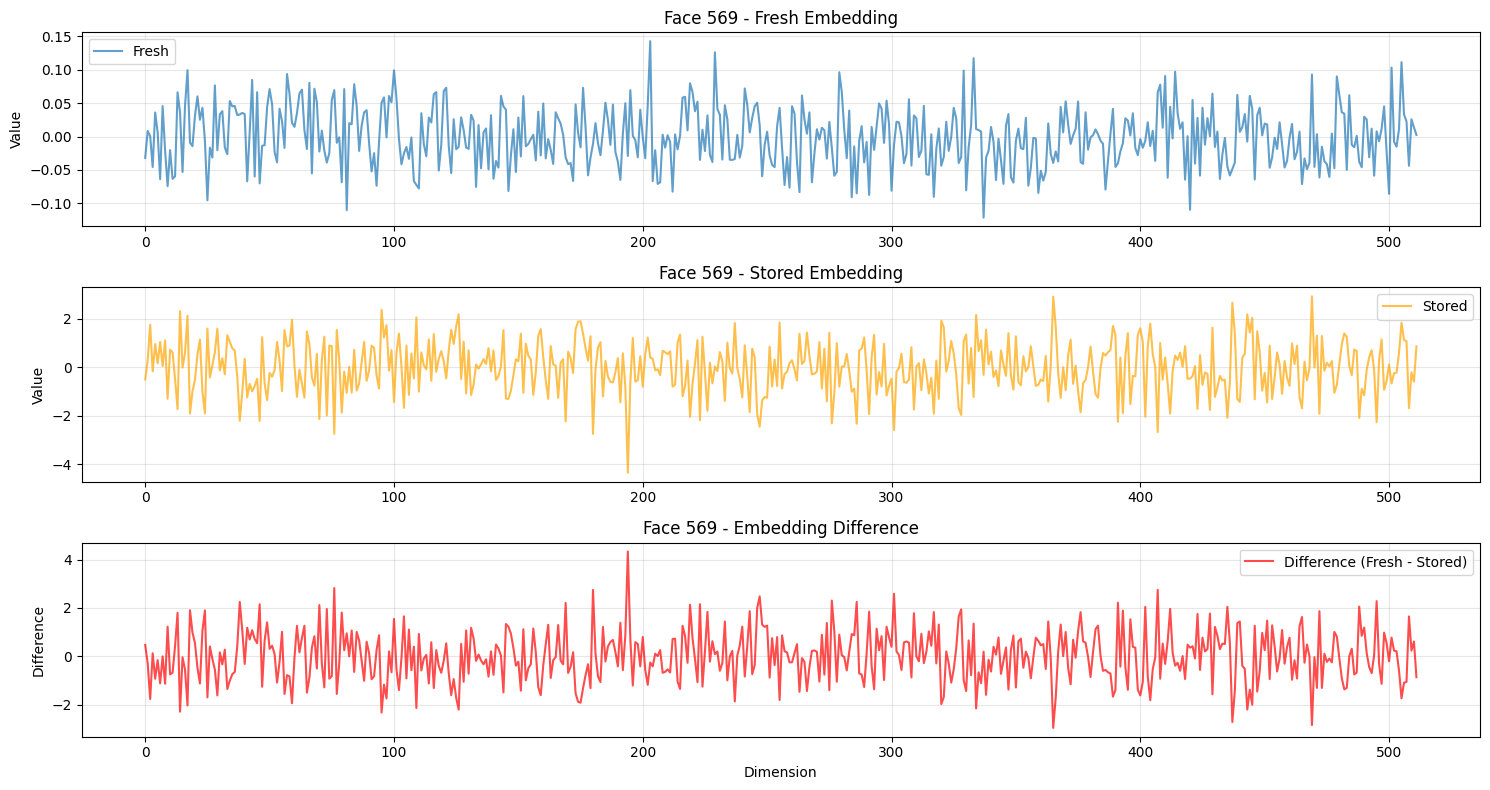


=== Embedding Comparison for Face 569 ===
L2 distance: 24.143038
Max absolute difference: 4.332201
Mean absolute difference: 0.852937
Cosine similarity: 0.080864
Cosine distance: 0.919136


In [14]:
# Compare embedding vectors visually for target face
if target_face in fresh_embeddings and target_face in stored_lookup:
    fresh_emb = fresh_embeddings[target_face]
    stored_emb = stored_lookup[target_face]
    
    fig, axes = plt.subplots(3, 1, figsize=(15, 8))
    
    # Plot fresh embedding
    axes[0].plot(fresh_emb, label='Fresh', alpha=0.7)
    axes[0].set_title(f"Face {target_face} - Fresh Embedding")
    axes[0].set_ylabel("Value")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    # Plot stored embedding
    axes[1].plot(stored_emb, label='Stored', alpha=0.7, color='orange')
    axes[1].set_title(f"Face {target_face} - Stored Embedding")
    axes[1].set_ylabel("Value")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    # Plot difference
    diff = fresh_emb - stored_emb
    axes[2].plot(diff, label='Difference (Fresh - Stored)', alpha=0.7, color='red')
    axes[2].set_title(f"Face {target_face} - Embedding Difference")
    axes[2].set_ylabel("Difference")
    axes[2].set_xlabel("Dimension")
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Statistics
    print(f"\n=== Embedding Comparison for Face {target_face} ===")
    print(f"L2 distance: {np.linalg.norm(diff):.6f}")
    print(f"Max absolute difference: {np.max(np.abs(diff)):.6f}")
    print(f"Mean absolute difference: {np.mean(np.abs(diff)):.6f}")
    
    cos_sim = np.dot(fresh_emb, stored_emb) / (np.linalg.norm(fresh_emb) * np.linalg.norm(stored_emb))
    print(f"Cosine similarity: {cos_sim:.6f}")
    print(f"Cosine distance: {1 - cos_sim:.6f}")

## 8. Conclusions

**What to look for**:
1. **Fresh vs Stored**: If diff > 0.01, embeddings were extracted differently (different model, preprocessing, or source images)
2. **Stored vs kNN**: If diff > 0.001, there's a mismatch in distance calculation or wrong embeddings were used
3. **Embedding vectors**: Visual comparison shows if embeddings are completely different or just slightly off

**Possible issues**:
- Different preprocessing (alignment, normalization)
- Different models (InsightFace vs Custom ArcFace)
- Face ID mismatch (stored embedding for face X is actually from face Y)
- Calculation error (wrong formula for cosine distance)